
# IGBT transient inverse PINN report

This notebook was generated automatically from `transient_inverse_pinn_igbt.py`.

## What is inside

- Surface-temperature-constrained transient PINN training
- Automatic solder-band inference from the COMSOL point cloud
- Inverse estimation of solder thermal conductivity ratio
- Ablations:
  - `data_only_seq`
  - `steady_like_no_time`
  - `transient_fixed_k`
  - `transient_inverse_no_rba`
  - `transient_inverse_full`

## Core assumptions

- The CSV is interpreted as a transient 3D thermal field with 13 time steps.
- The top surface (`z = 0.005827 m`) acts as the infrared-observed surface.
- The solder band is auto-detected in `z in [0.005007, 0.005327] m`.
- Conductivity is reported both as a relative ratio and via a configurable nominal value (`50.0 W/mK`).

## Prominent z planes

0.005827, 0.005647, 0.005627, 0.005477, 0.005327, 0.005007, 0.004707, 0.004507, 0.001507, 0.001407


In [1]:

from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, display

root = Path.cwd()
results_dir = root / "transient_inverse_pinn_results"
metrics = pd.read_csv(results_dir / "ablation_metrics.csv")
metrics


,model,runtime_sec,best_epoch,surface_test_rmse_c,surface_test_mae_c,surface_test_mape_pct,surface_test_r2,surface_test_peak_error_c,full_field_rmse_c,full_field_mae_c,full_field_r2,k_ratio,k_solder_wmk,aging_ratio,alpha_base,source_gain
0,data_only_seq,4.234290,120,3.553048,2.644001,2.442585,0.977493,8.348495,20.828516,14.717191,-0.189933,1.0,50.0,0.0,0.301194,0.606531
1,transient_inverse_no_rba,57.851189,59,3.624970,2.534725,2.312256,0.976573,7.228516,20.127834,13.226827,-0.111220,1.0,50.0,0.0,0.301194,0.606531
2,transient_inverse_full,57.927359,59,3.624970,2.534725,2.312256,0.976573,7.228516,20.127834,13.226827,-0.111220,1.0,50.0,0.0,0.301194,0.606531
3,steady_like_no_time,57.562761,54,3.762637,2.703559,2.433204,0.974760,11.165573,19.779251,13.039634,-0.073064,1.0,50.0,0.0,0.301194,0.606531
4,transient_fixed_k,57.064611,54,3.762637,2.703559,2.433204,0.974760,11.165573,19.779251,13.039634,-0.073064,1.0,50.0,0.0,0.301194,0.606531


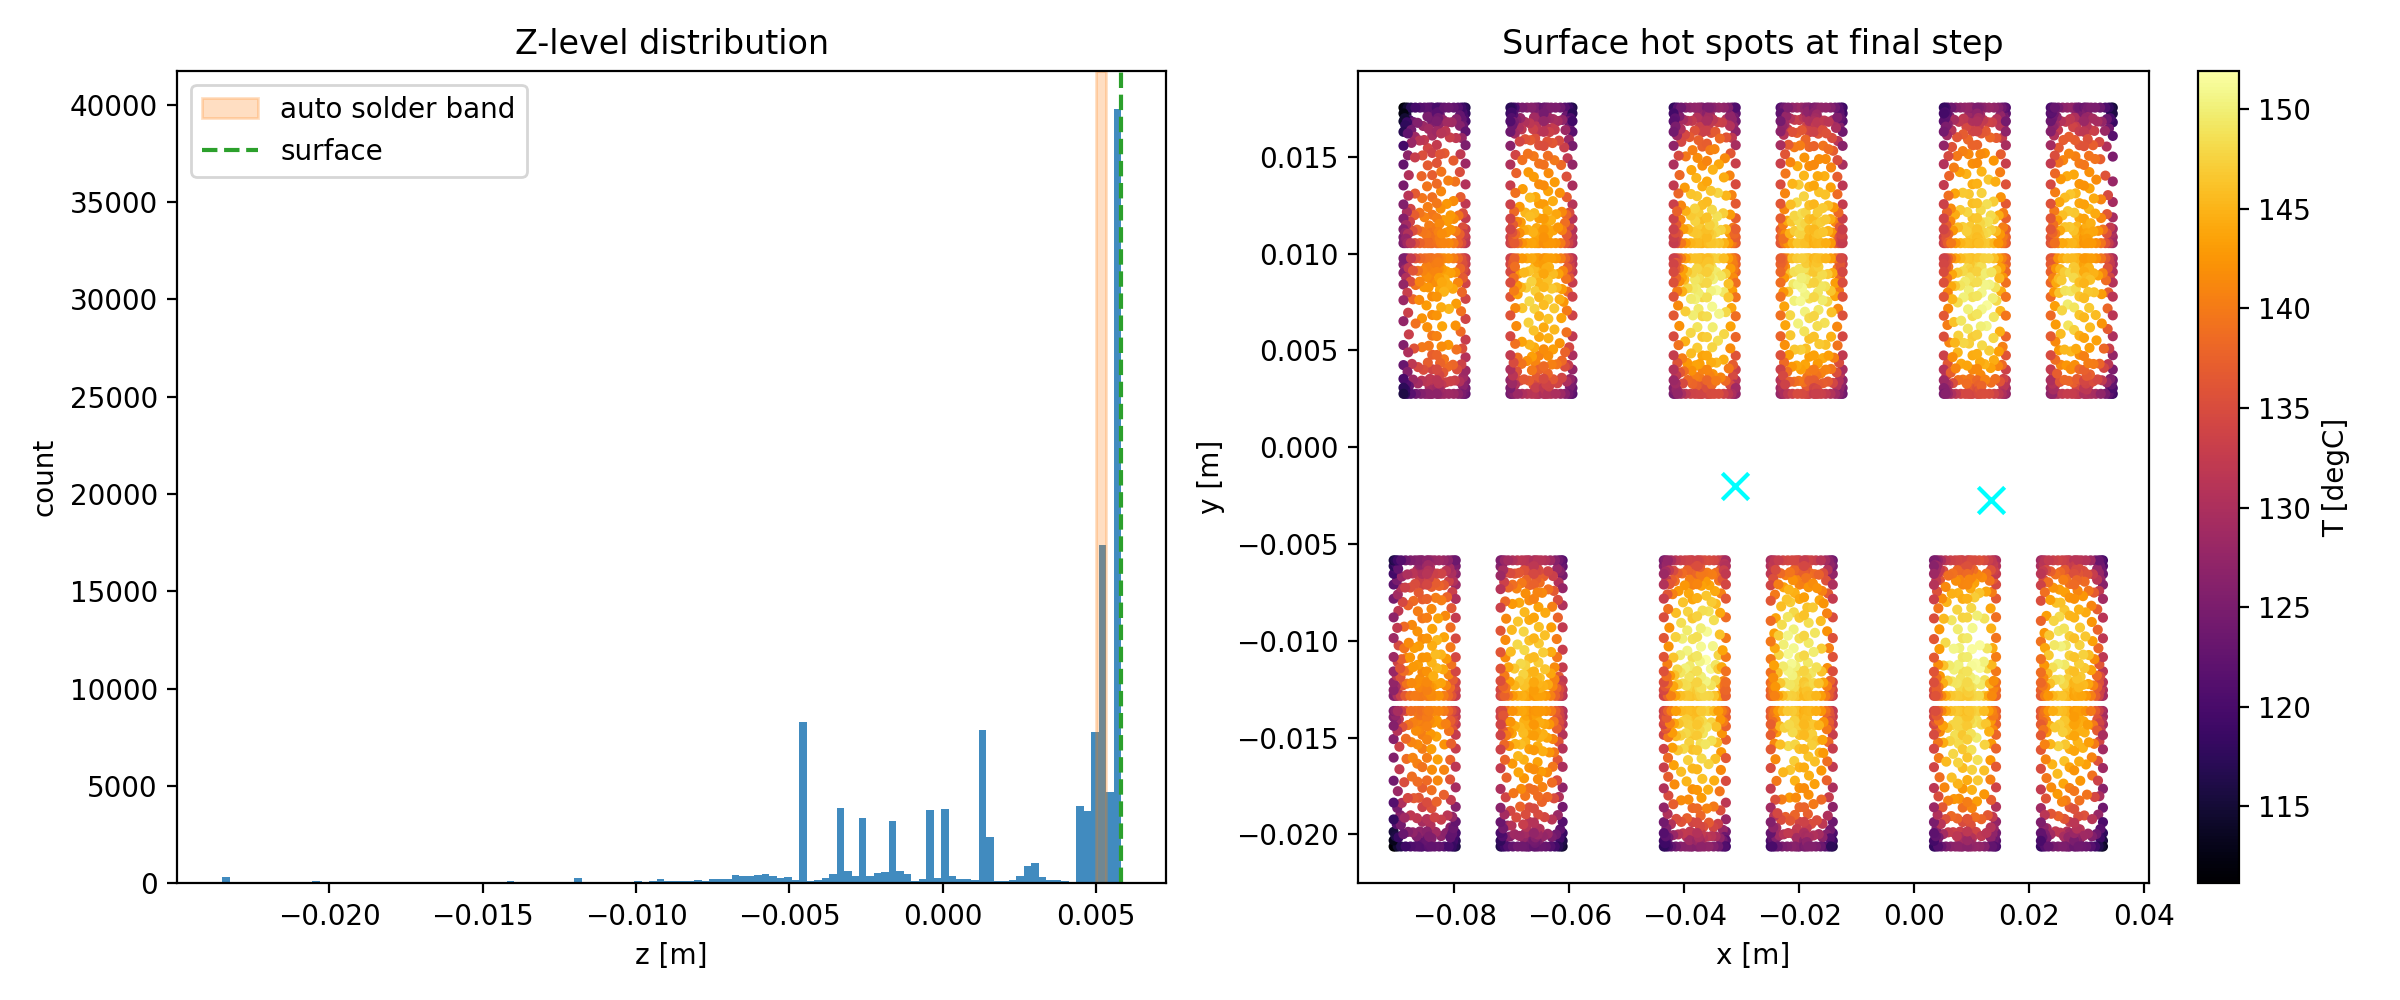

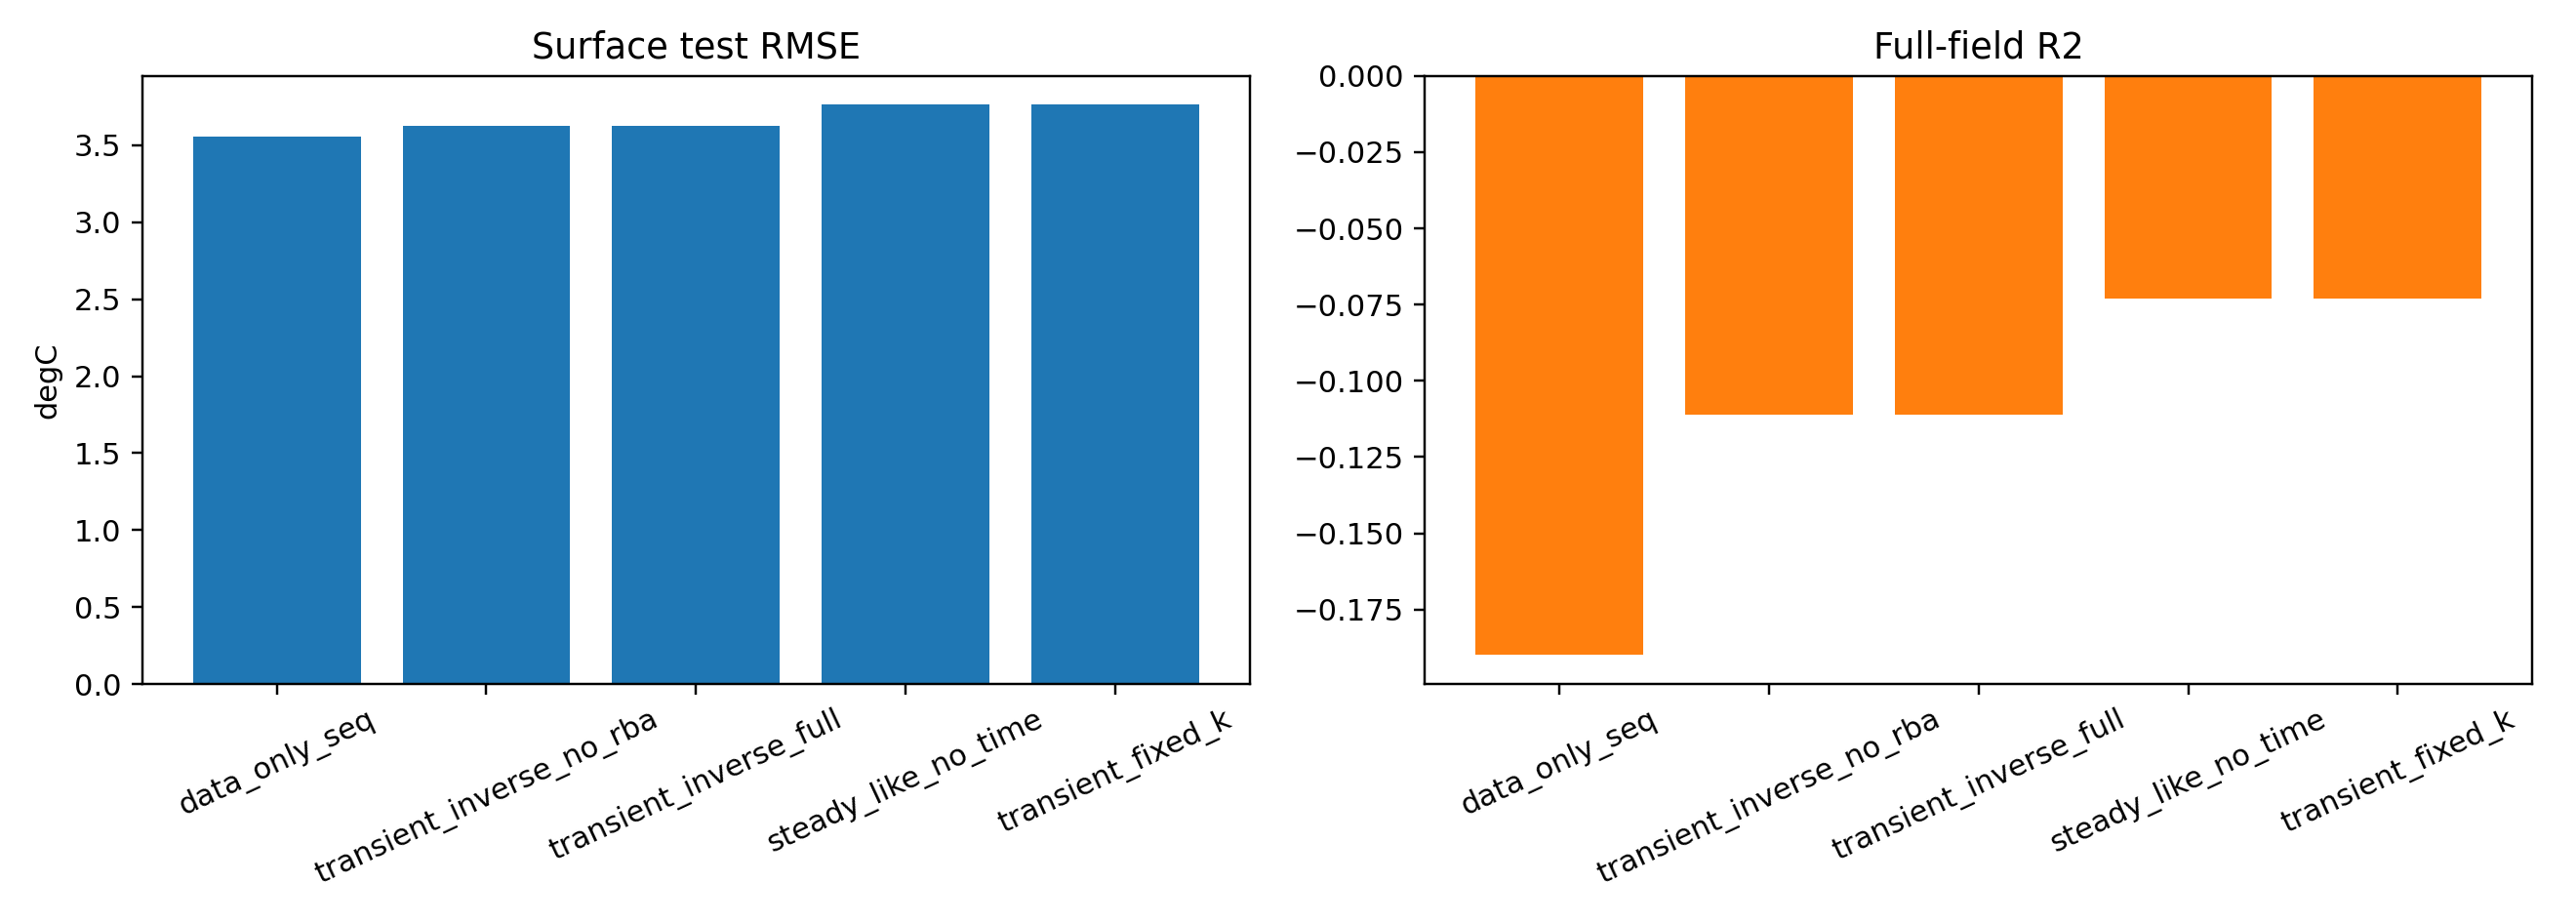

In [2]:

display(Image(filename=str(results_dir / "geometry_inference.png")))
display(Image(filename=str(results_dir / "ablation_summary.png")))


In [3]:

best = metrics.sort_values("surface_test_rmse_c").iloc[0]
best


model                        data_only_seq
runtime_sec                        4.23429
best_epoch                             120
surface_test_rmse_c               3.553048
surface_test_mae_c                2.644001
surface_test_mape_pct             2.442585
surface_test_r2                   0.977493
surface_test_peak_error_c         8.348495
full_field_rmse_c                20.828516
full_field_mae_c                 14.717191
full_field_r2                    -0.189933
k_ratio                                1.0
k_solder_wmk                          50.0
aging_ratio                            0.0
alpha_base                        0.301194
source_gain                       0.606531
Name: 0, dtype: object

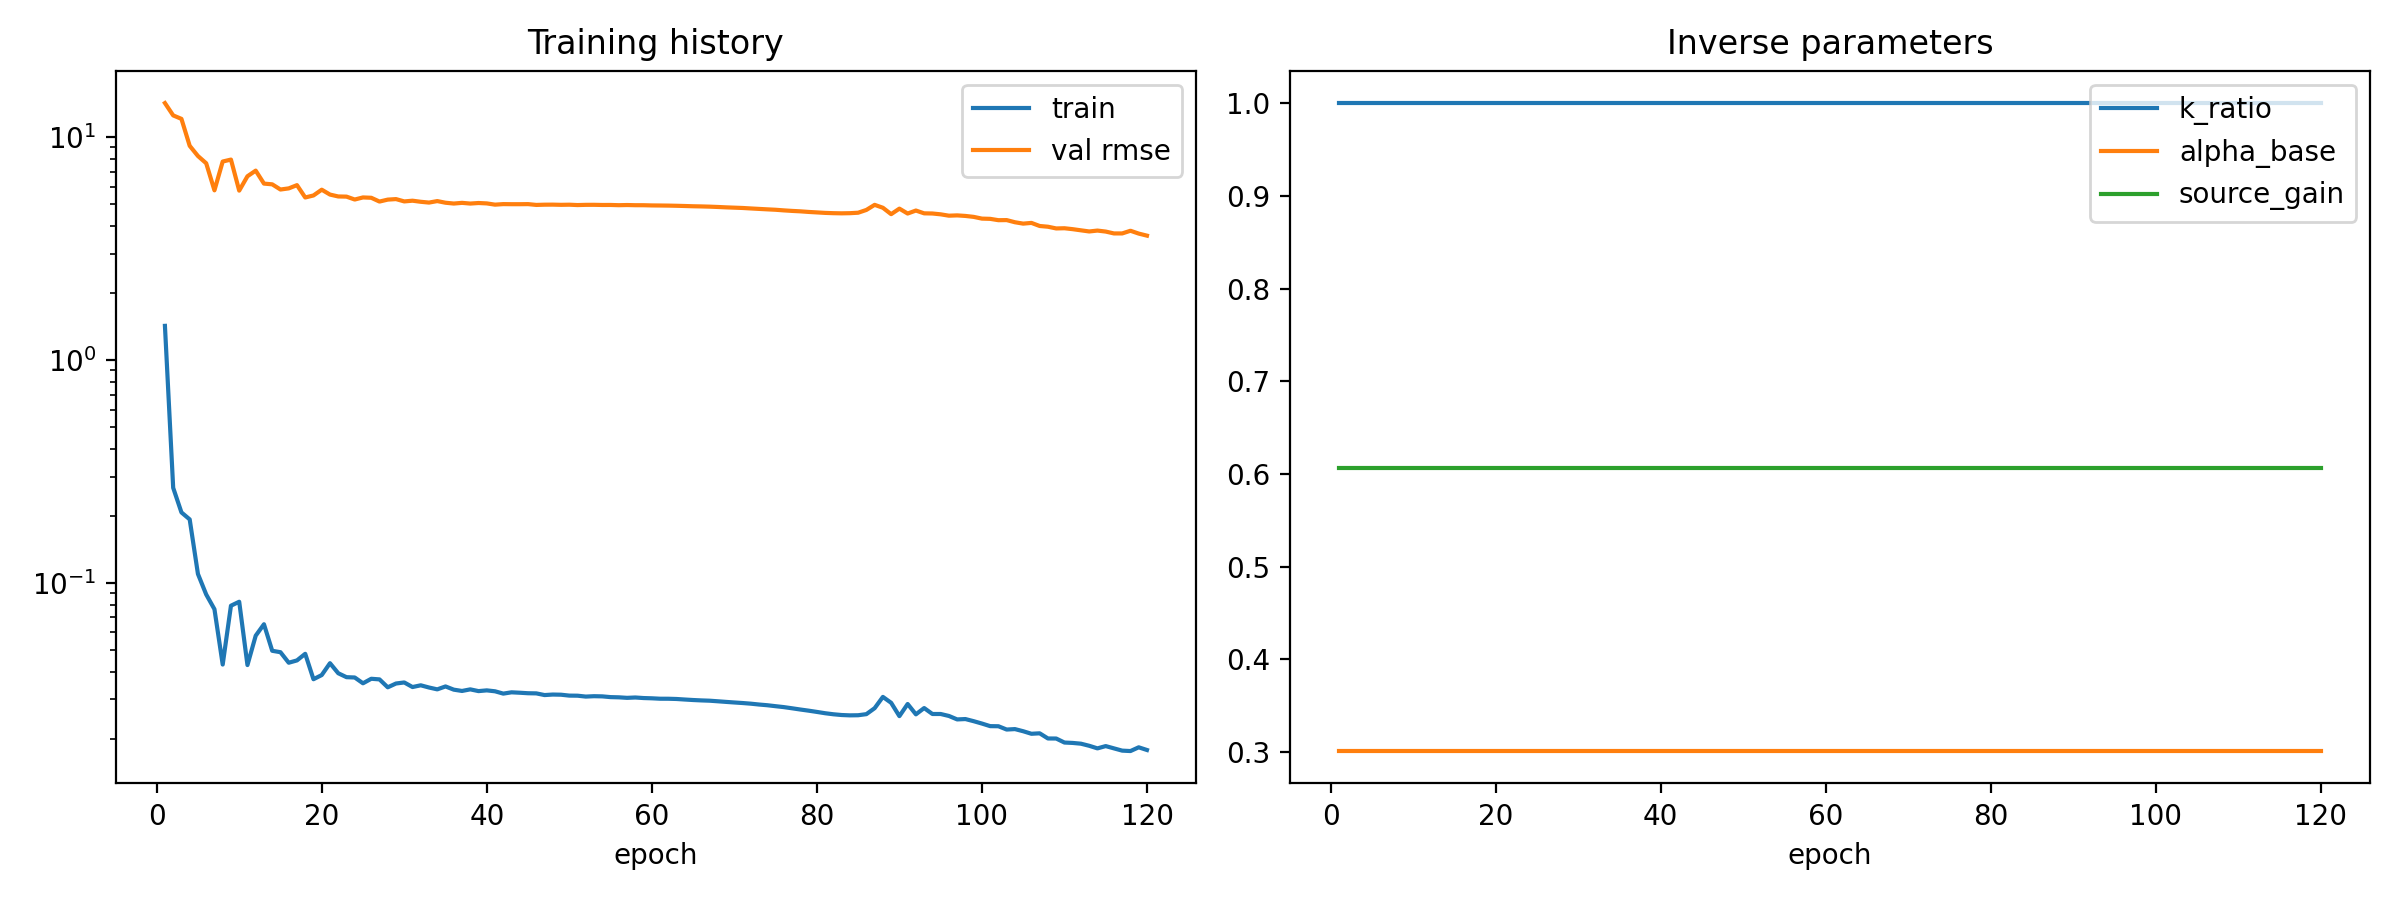

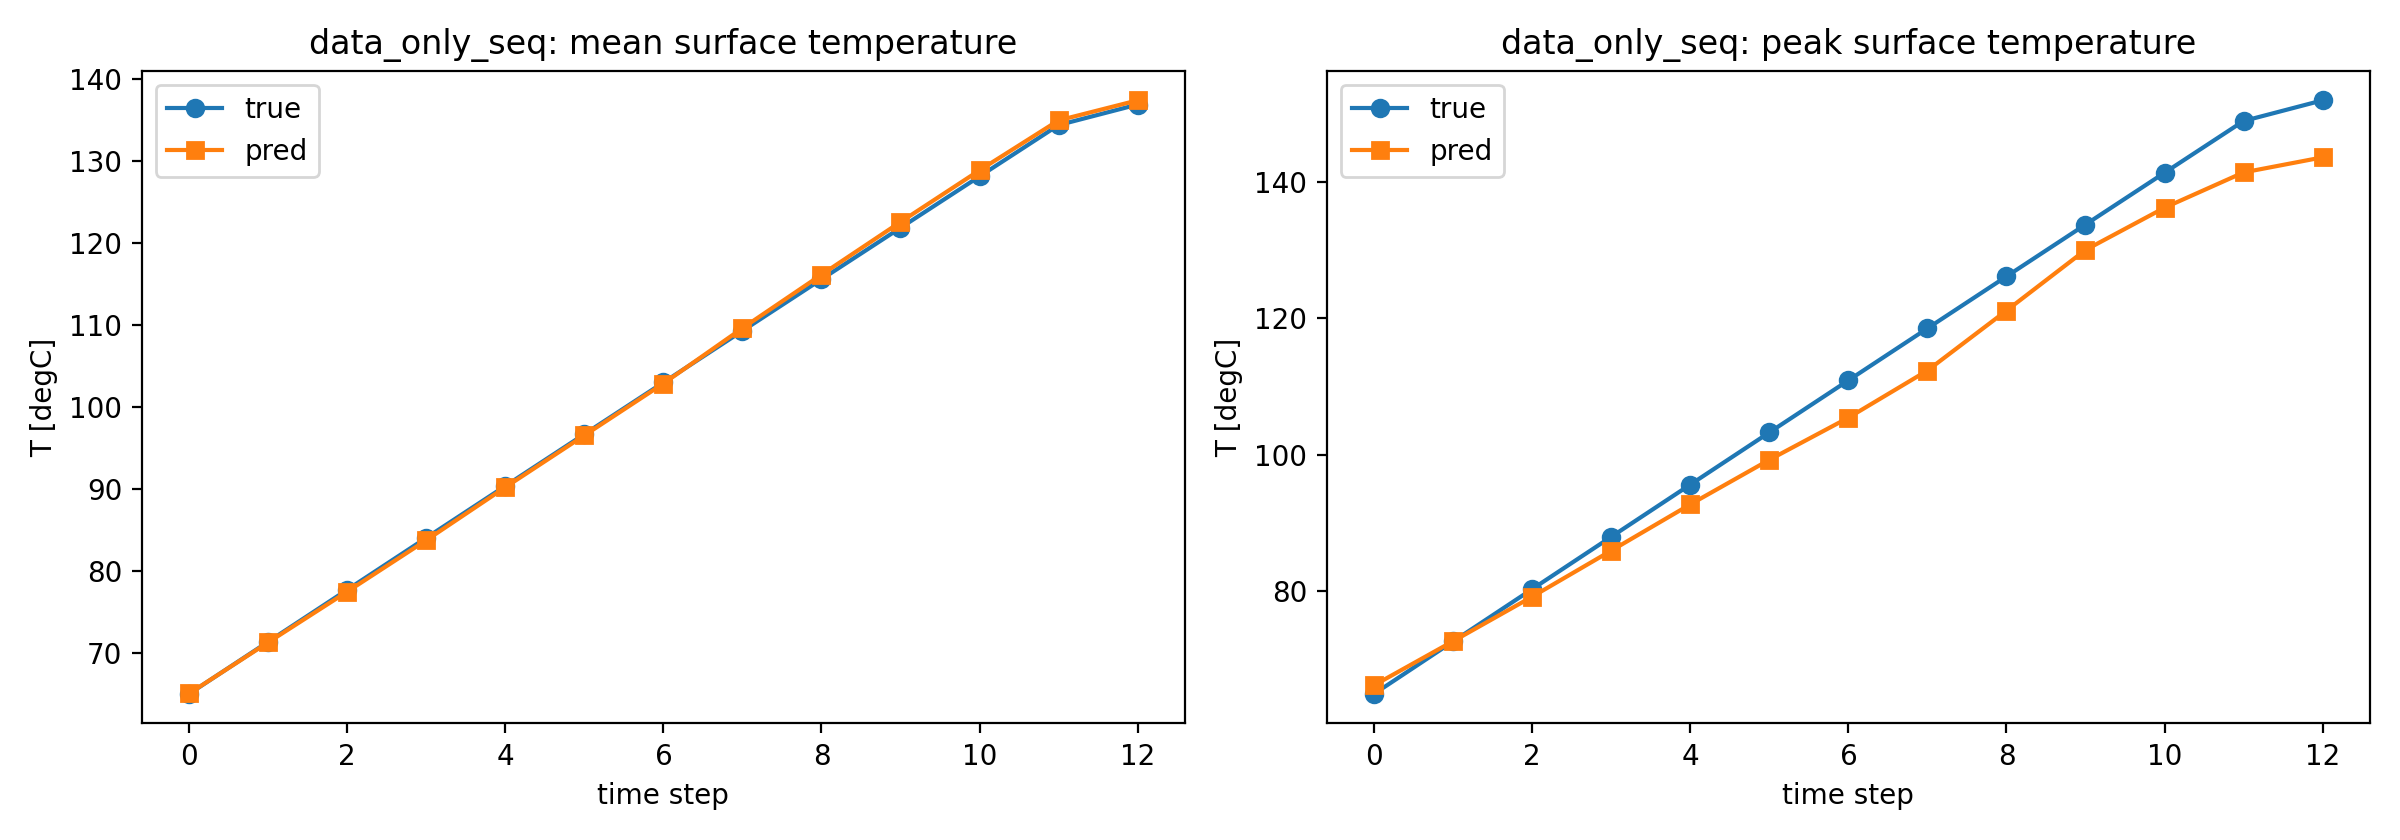

In [4]:

best_name = best["model"]
display(Image(filename=str(results_dir / f"{best_name}_history.png")))
display(Image(filename=str(results_dir / f"{best_name}_rollout.png")))


In [5]:

summaries = {}
for path in sorted(results_dir.glob("*_summary.json")):
    with open(path, "r", encoding="utf-8") as f:
        summaries[path.stem.replace("_summary", "")] = json.load(f)
summaries


{'data_only_seq': {'model': 'data_only_seq',
  'runtime_sec': 4.234289884567261,
  'best_epoch': 120,
  'surface_test_rmse_c': 3.5530476570129395,
  'surface_test_mae_c': 2.6440014839172363,
  'surface_test_mape_pct': 2.442585490643978,
  'surface_test_r2': 0.9774931701972812,
  'surface_test_peak_error_c': 8.348495483398438,
  'full_field_rmse_c': 20.828516006469727,
  'full_field_mae_c': 14.717190742492676,
  'full_field_r2': -0.1899332018722999,
  'k_ratio': 1.0,
  'k_solder_wmk': 50.0,
  'aging_ratio': 0.0,
  'alpha_base': 0.3011941909790039,
  'source_gain': 0.6065306663513184},
 'steady_like_no_time': {'model': 'steady_like_no_time',
  'runtime_sec': 57.562761306762695,
  'best_epoch': 54,
  'surface_test_rmse_c': 3.76263689994812,
  'surface_test_mae_c': 2.7035586833953857,
  'surface_test_mape_pct': 2.4332039058208466,
  'surface_test_r2': 0.974759562438085,
  'surface_test_peak_error_c': 11.165573120117188,
  'full_field_rmse_c': 19.779251098632812,
  'full_field_mae_c': 13.03